In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import matplotlib.pyplot as plt
import os
import pandas as pd

os.environ['KMP_DUPLICATE_LIB_OK']='True'

In [24]:
# Dataset path and model configuration
dataset_root  = r"/kaggle/input/datasets/abdulraufafridi/apple-dataset"
model_name = "mobilenetv2_100"
no_classes = 9
image_size = 640
num_epochs = 100
batch_size = 8
learning_rate = 0.001

In [25]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [26]:
# Model Definition
class ImageClassifier(nn.Module):
    def __init__(self, num_classes, model_name):
        super(ImageClassifier, self).__init__()
        if model_name == "mobilenetv2_100":
            self.model = models.mobilenet_v2(weights=True)
            self.model.classifier[1] = nn.Linear(self.model.last_channel, num_classes)

    def forward(self, x):
        return self.model(x)

In [27]:
# Instantiate the model
model = ImageClassifier(no_classes, model_name).to(device)

In [28]:
# Define optimizer and loss function
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()

In [29]:
# Define transforms
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [30]:
# Load datasets
train_dataset = ImageFolder(root=os.path.join(dataset_root, "train"), transform=transform)
validation_dataset = ImageFolder(root=os.path.join(dataset_root, "test"), transform=transform)

In [31]:
# Dataloaders
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
validation_dataloader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=True)

In [32]:
# Training and Validation
training_loss_arr = []
validation_loss_arr = []
training_acc_arr = []
validation_acc_arr = []

for epoch in range(num_epochs):
    # Training loop
    model.train()
    total_train_loss = 0.0
    total_train_correct = 0
    total_train_samples = 0
    
    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

        # Calculate accuracy
        _, predicted = torch.max(outputs.data, 1)
        total_train_correct += (predicted == labels).sum().item()
        total_train_samples += labels.size(0)

    avg_train_loss = total_train_loss / len(train_dataloader)
    training_loss_arr.append(avg_train_loss)
    
    train_accuracy = total_train_correct / total_train_samples * 100
    training_acc_arr.append(train_accuracy)

    # Validation loop
    model.eval()
    total_val_loss = 0.0
    total_val_correct = 0
    total_val_samples = 0

    with torch.no_grad():
        for images, labels in validation_dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss = criterion(outputs, labels)
            total_val_loss += val_loss.item()

            # Calculate accuracy
            _, predicted = torch.max(outputs.data, 1)
            total_val_correct += (predicted == labels).sum().item()
            total_val_samples += labels.size(0)

    avg_val_loss = total_val_loss / len(validation_dataloader)
    validation_loss_arr.append(avg_val_loss)

    val_accuracy = total_val_correct / total_val_samples * 100
    validation_acc_arr.append(val_accuracy)

    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, Train Acc: {train_accuracy:.2f}%, Val Acc: {val_accuracy:.2f}%")

    if (epoch + 1) % 10 == 0:
        torch.save(model.state_dict(), f"{model_name}_epoch{epoch+1}.pth")
        print(f"Model saved at epoch {epoch+1}.")

Epoch 1/100, Train Loss: 1.1068, Val Loss: 0.4862, Train Acc: 58.73%, Val Acc: 80.25%
Epoch 2/100, Train Loss: 0.6860, Val Loss: 0.3841, Train Acc: 74.60%, Val Acc: 86.42%
Epoch 3/100, Train Loss: 0.4810, Val Loss: 0.4696, Train Acc: 82.36%, Val Acc: 87.65%
Epoch 4/100, Train Loss: 0.4622, Val Loss: 0.3072, Train Acc: 84.48%, Val Acc: 85.19%
Epoch 5/100, Train Loss: 0.3796, Val Loss: 0.4548, Train Acc: 85.54%, Val Acc: 79.01%
Epoch 6/100, Train Loss: 0.4577, Val Loss: 0.7402, Train Acc: 84.83%, Val Acc: 90.12%
Epoch 7/100, Train Loss: 0.2785, Val Loss: 0.2545, Train Acc: 89.42%, Val Acc: 92.59%
Epoch 8/100, Train Loss: 0.3369, Val Loss: 0.1555, Train Acc: 88.71%, Val Acc: 95.06%
Epoch 9/100, Train Loss: 0.2046, Val Loss: 0.1148, Train Acc: 92.42%, Val Acc: 95.06%
Epoch 10/100, Train Loss: 0.1715, Val Loss: 0.1131, Train Acc: 94.18%, Val Acc: 97.53%
Model saved at epoch 10.
Epoch 11/100, Train Loss: 0.1994, Val Loss: 0.2368, Train Acc: 93.12%, Val Acc: 92.59%
Epoch 12/100, Train Loss: 0

In [33]:
# Save the final model
torch.save(model.state_dict(), f"{model_name}_final.pth")
print(f"Final model saved as {model_name}_final.pth.")

Final model saved as mobilenetv2_100_final.pth.


In [34]:
# Save loss and accuracy data to CSV
df = pd.DataFrame({'train_loss': training_loss_arr, 'val_loss': validation_loss_arr,
                   'train_acc': training_acc_arr, 'val_acc': validation_acc_arr})
df.to_csv('train_val_loss_acc.csv', index=False)

In [35]:
# Plot loss and accuracy curves
plt.figure(figsize=(12, 6), dpi=300)

<Figure size 3600x1800 with 0 Axes>

<Figure size 3600x1800 with 0 Axes>

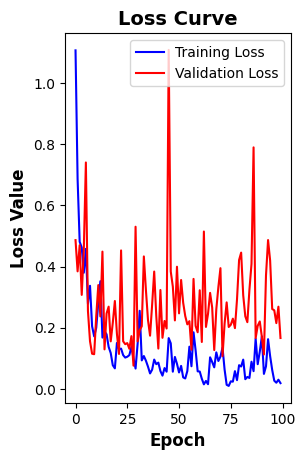

In [36]:
# Plot loss curves
plt.subplot(1, 2, 1)
plt.plot(training_loss_arr, label="Training Loss", color='b')
plt.plot(validation_loss_arr, label="Validation Loss", color='r')
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Loss Value', fontsize=12, fontweight='bold')
plt.title('Loss Curve', fontsize=14, fontweight='bold')
plt.legend()

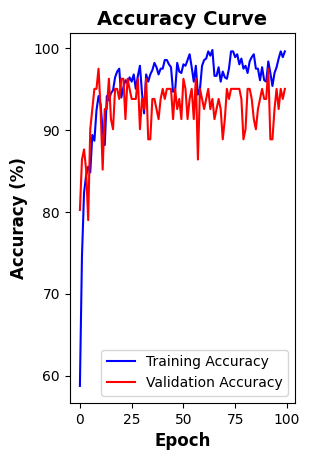

In [37]:
# Plot accuracy curves
plt.subplot(1, 2, 2)
plt.plot(training_acc_arr, label="Training Accuracy", color='b')
plt.plot(validation_acc_arr, label="Validation Accuracy", color='r')
plt.xlabel('Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
plt.title('Accuracy Curve', fontsize=14, fontweight='bold')
plt.legend()

In [38]:
# Save the plots
plt.savefig('loss_acc_curve.eps', format='eps', bbox_inches='tight')
plt.show()

<Figure size 640x480 with 0 Axes>